# Namma Metro Station Hourly Ridership — Dataset Analysis

Initial exploratory analysis of the station-hourly ridership dataset.

In [2]:
import pandas as pd
from pathlib import Path

DATASET_PATH = Path("../datasets/raw/station-hourly.csv")
df = pd.read_csv(DATASET_PATH, sep=";")

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
print("Columns:", list(df.columns))

Rows: 92,280
Columns: 4
Columns: ['Date', 'Hour', 'Station', 'Ridership']


In [1]:
from pathlib import Path
print(Path.cwd())

c:\Users\likit\OneDrive\Desktop\Predictive-Public-Transit-Intelligence-Platform-for-Crowd-management-and-Schedule-Optimization\MetroFlow\ai


In [6]:
# ==============================
# 3. Prepare Weather Dataset
# ==============================

weather_aug_sep = weather_df[
    (weather_df['month'].isin([8, 9]))
].copy()

weather_aug_sep['Date'] = pd.to_datetime(
    weather_aug_sep[['year', 'month', 'day']]
)

weather_aug_sep = weather_aug_sep[
    ['Date', 'hour', 'temp', 'rhum', 'prcp', 'wspd', 'pres', 'cldc', 'coco']
]

weather_aug_sep.head()

,Date,hour,temp,rhum,prcp,wspd,pres,cldc,coco
5088,2025-08-01,0,21.2,93,0.0,11.2,1012.0,6,3
5089,2025-08-01,1,20.0,94,0.0,14.8,1013.0,4,3
5090,2025-08-01,2,21.0,94,0.0,14.8,1013.0,4,3
5091,2025-08-01,3,22.4,85,0.0,16.6,1014.0,6,3
5092,2025-08-01,4,24.0,83,0.0,16.6,1014.0,2,3


In [7]:
metro_path = Path("../datasets/raw/station-hourly.csv")

metro_df = pd.read_csv(
    metro_path,
    sep=";"
)

metro_df["Date"] = pd.to_datetime(metro_df["Date"])

metro_df.head()

,Date,Hour,Station,Ridership
0,2025-08-01,0,Attiguppe,0
1,2025-08-01,1,Attiguppe,0
2,2025-08-01,2,Attiguppe,0
3,2025-08-01,3,Attiguppe,0
4,2025-08-01,4,Attiguppe,6


In [5]:
from pathlib import Path
import pandas as pd

weather_path = Path("../datasets/raw/bengaluru-weather-2025.csv")
weather_df = pd.read_csv(weather_path)

weather_df.head()

,year,month,day,hour,temp,temp_source,rhum,rhum_source,prcp,prcp_source,...,wspd,wspd_source,wpgt,wpgt_source,pres,pres_source,cldc,cldc_source,coco,coco_source
0,2025,1,1,0,18.4,isd_lite,86,isd_lite,0.0,dwd_mosmix,...,7.6,isd_lite,NaN,NaN,1018.0,metar,3,isd_lite,5,metar
1,2025,1,1,1,18.0,isd_lite,94,isd_lite,0.0,dwd_mosmix,...,7.6,isd_lite,NaN,NaN,1019.0,metar,5,dwd_mosmix,5,metar
2,2025,1,1,2,19.0,isd_lite,94,isd_lite,0.0,dwd_mosmix,...,7.6,isd_lite,NaN,NaN,1019.0,metar,5,dwd_mosmix,5,metar
3,2025,1,1,3,19.2,isd_lite,82,isd_lite,0.0,dwd_mosmix,...,11.2,isd_lite,NaN,NaN,1020.0,metar,4,isd_lite,5,metar
4,2025,1,1,4,23.0,isd_lite,69,isd_lite,0.0,dwd_mosmix,...,14.8,isd_lite,NaN,NaN,1020.0,metar,4,dwd_mosmix,5,metar


In [8]:
metro_df.shape

(92280, 4)

In [ ]:
# Preview the data
df.head(10)

In [9]:
metro_df["Date"].min(), metro_df["Date"].max()

(Timestamp('2025-08-01 00:00:00'), Timestamp('2025-09-30 00:00:00'))

In [ ]:
# Data types and missing values
print("Data types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

In [10]:
# Merge Metro ridership with weather data

merged_df = metro_df.merge(
    weather_aug_sep,
    left_on=["Date", "Hour"],
    right_on=["Date", "hour"],
    how="left"
)

merged_df.head()

,Date,Hour,Station,Ridership,hour,temp,rhum,prcp,wspd,pres,cldc,coco
0,2025-08-01,0,Attiguppe,0,0,21.2,93,0.0,11.2,1012.0,6,3
1,2025-08-01,1,Attiguppe,0,1,20.0,94,0.0,14.8,1013.0,4,3
2,2025-08-01,2,Attiguppe,0,2,21.0,94,0.0,14.8,1013.0,4,3
3,2025-08-01,3,Attiguppe,0,3,22.4,85,0.0,16.6,1014.0,6,3
4,2025-08-01,4,Attiguppe,6,4,24.0,83,0.0,16.6,1014.0,2,3


In [11]:
merged_df.shape

(92280, 12)

In [ ]:
# Duplicate records
print(f"Duplicate rows: {df.duplicated().sum():,}")

In [12]:
merged_df.isna().sum()

Date         0
Hour         0
Station      0
Ridership    0
hour         0
temp         0
rhum         0
prcp         0
wspd         0
pres         0
cldc         0
coco         0
dtype: int64

In [ ]:
# Date, hour and station information
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Number of stations: {df['Station'].nunique():,}")
print(f"Hour range: {df['Hour'].min()} to {df['Hour'].max()}")

In [ ]:
# Ridership statistics
df["Ridership"].describe()

In [13]:
import os

print(os.path.abspath("../datasets/processed/metro_weather_merged.csv"))
print(os.path.exists("../datasets/processed/metro_weather_merged.csv"))

c:\Users\likit\OneDrive\Desktop\Predictive-Public-Transit-Intelligence-Platform-for-Crowd-management-and-Schedule-Optimization\MetroFlow\datasets\processed\metro_weather_merged.csv
False


In [ ]:
# Highest-ridership station-hour records
df.nlargest(10, "Ridership")[["Date", "Hour", "Station", "Ridership"]]

In [ ]:
# Average ridership by hour
hourly_avg = (
    df.groupby("Hour")["Ridership"]
      .mean()
      .sort_values(ascending=False)
)
hourly_avg

In [14]:
# Save the merged dataset

processed_path = Path("../datasets/processed/metro_weather_merged.csv")

merged_df.to_csv(processed_path, index=False)

print("Saved successfully!")
print("Rows:", len(merged_df))
print("Columns:", len(merged_df.columns))

Saved successfully!
Rows: 92280
Columns: 12


In [ ]:
# Average ridership by station
station_avg = (
    df.groupby("Station")["Ridership"]
      .mean()
      .sort_values(ascending=False)
)
station_avg.head(20)

In [15]:
print(os.path.exists("../datasets/processed/metro_weather_merged.csv"))

True


In [16]:
# Weather vs Metro Ridership

weather_ridership = merged_df[
    ['Ridership', 'temp', 'rhum', 'prcp', 'wspd']
].corr()

weather_ridership

,Ridership,temp,rhum,prcp,wspd
Ridership,1.000000,0.159711,-0.140534,0.074771,-0.033485
temp,0.159711,1.000000,-0.937051,0.087938,-0.010455
rhum,-0.140534,-0.937051,1.000000,-0.025288,-0.078355
prcp,0.074771,0.087938,-0.025288,1.000000,-0.098310
wspd,-0.033485,-0.010455,-0.078355,-0.098310,1.000000


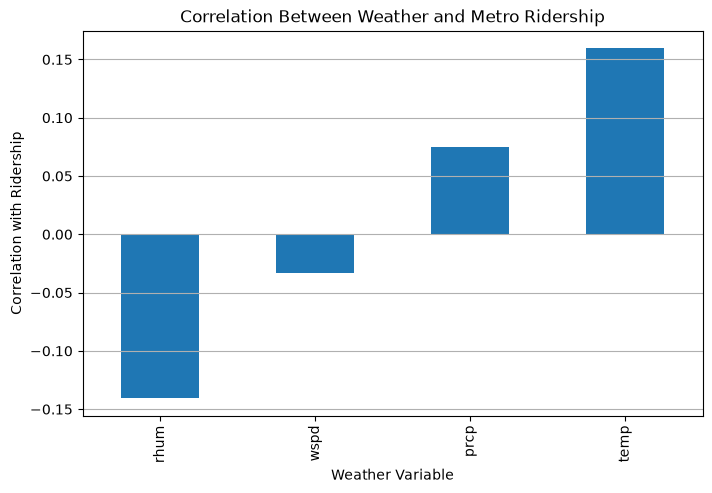

In [17]:
import matplotlib.pyplot as plt

weather_ridership['Ridership'].drop('Ridership').sort_values().plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Correlation Between Weather and Metro Ridership')
plt.xlabel('Weather Variable')
plt.ylabel('Correlation with Ridership')
plt.grid(axis='y')
plt.show()

In [18]:
# Station-wise ridership analysis

station_ridership = (
    merged_df.groupby("Station")["Ridership"]
    .agg(["sum", "mean", "max"])
    .sort_values("sum", ascending=False)
)

station_ridership.head(10)

,sum,mean,max
Station,,,
"Nadaprabhu Kempegowda Station, Majestic",1649530,1431.883681,4365
Benniganahalli,1250656,1085.638889,4425
Indiranagar,1048936,910.534722,3871
Mahatma Gandhi Road,1007176,874.284722,4372
Krishnarajapura,904508,785.163194,3159
Mantri Square Sampige Road,796520,691.423611,2193
Chickpete,737856,640.500000,3360
Cubbon Park,666237,578.330729,3975
Yeshwantpur,666189,578.289062,2811


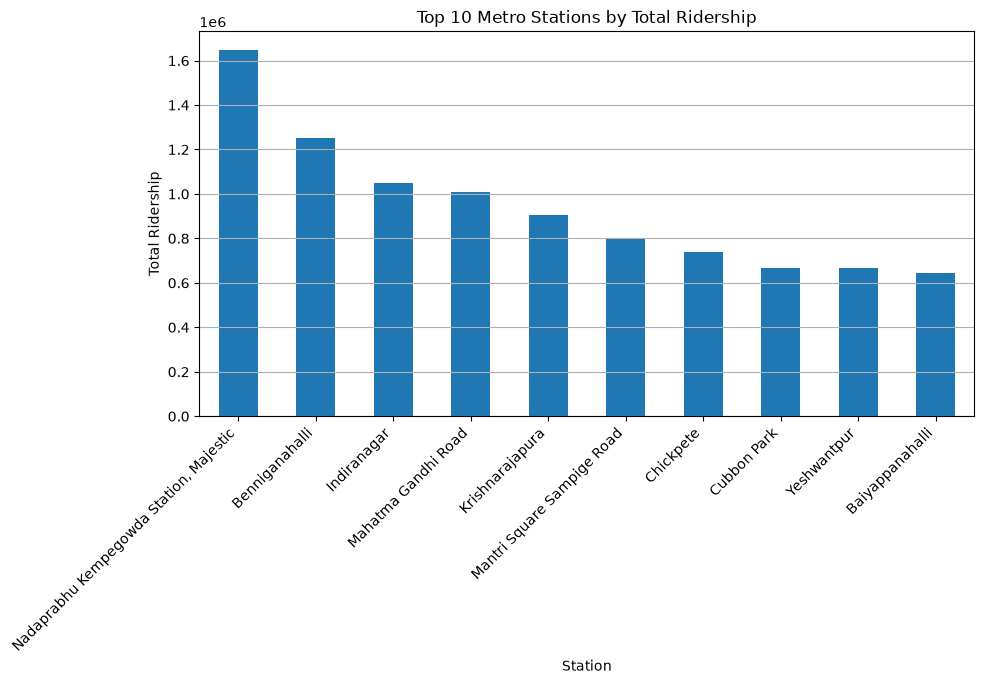

In [19]:
# Top 10 busiest stations by total ridership

station_ridership["sum"].head(10).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top 10 Metro Stations by Total Ridership")
plt.xlabel("Station")
plt.ylabel("Total Ridership")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()

In [20]:
# Peak-hour ridership analysis

hourly_ridership = (
    merged_df.groupby("Hour")["Ridership"]
    .mean()
    .sort_values(ascending=False)
)

hourly_ridership

Hour
18    866.081664
9     807.571131
17    746.497789
19    712.867620
8     685.021326
16    601.594018
10    591.263199
15    475.986216
20    474.144343
11    450.216125
13    447.210403
14    441.968531
12    431.883745
7     371.936541
21    301.533680
22    165.198440
6     139.185176
5      55.804941
23     22.361508
4      11.826528
0       0.173212
3       0.163329
1       0.000000
2       0.000000
Name: Ridership, dtype: float64

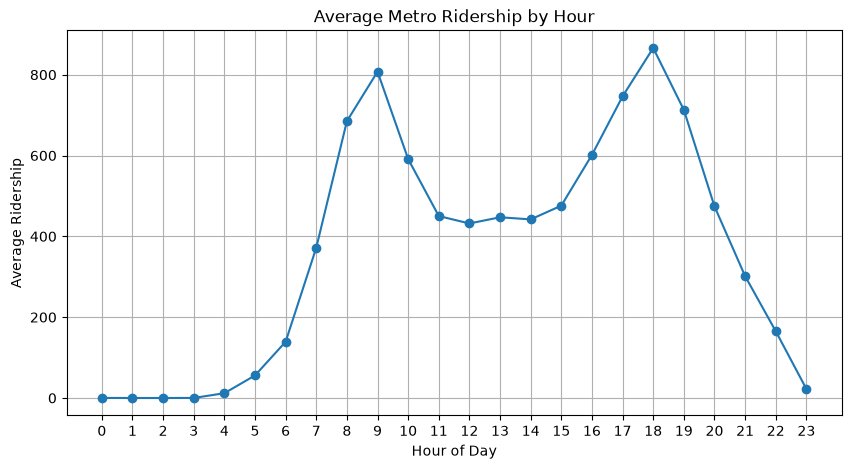

In [21]:
# Average ridership by hour

hourly_ridership.sort_index().plot(
    kind="line",
    marker="o",
    figsize=(10, 5)
)

plt.title("Average Metro Ridership by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Ridership")
plt.xticks(range(24))
plt.grid(True)
plt.show()

In [22]:
# Create ML-ready features

ml_df = merged_df.copy()

# Time-based features
ml_df["DayOfWeek"] = ml_df["Date"].dt.dayofweek
ml_df["IsWeekend"] = (ml_df["DayOfWeek"] >= 5).astype(int)

# Peak-hour indicator
ml_df["IsPeakHour"] = ml_df["Hour"].isin(
    [7, 8, 9, 17, 18, 19, 20]
).astype(int)

# Rain indicator
ml_df["IsRainy"] = (ml_df["prcp"] > 0).astype(int)

ml_df.head()

,Date,Hour,Station,Ridership,hour,temp,rhum,prcp,wspd,pres,cldc,coco,DayOfWeek,IsWeekend,IsPeakHour,IsRainy
0,2025-08-01,0,Attiguppe,0,0,21.2,93,0.0,11.2,1012.0,6,3,4,0,0,0
1,2025-08-01,1,Attiguppe,0,1,20.0,94,0.0,14.8,1013.0,4,3,4,0,0,0
2,2025-08-01,2,Attiguppe,0,2,21.0,94,0.0,14.8,1013.0,4,3,4,0,0,0
3,2025-08-01,3,Attiguppe,0,3,22.4,85,0.0,16.6,1014.0,6,3,4,0,0,0
4,2025-08-01,4,Attiguppe,6,4,24.0,83,0.0,16.6,1014.0,2,3,4,0,0,0


In [23]:
ml_df.columns.tolist()

['Date',
 'Hour',
 'Station',
 'Ridership',
 'hour',
 'temp',
 'rhum',
 'prcp',
 'wspd',
 'pres',
 'cldc',
 'coco',
 'DayOfWeek',
 'IsWeekend',
 'IsPeakHour',
 'IsRainy']

In [24]:
# Prepare target variable

ml_df["TargetRidership"] = ml_df["Ridership"]

ml_df[[
    "Date",
    "Hour",
    "Station",
    "Ridership",
    "TargetRidership",
    "temp",
    "rhum",
    "prcp",
    "IsWeekend",
    "IsPeakHour",
    "IsRainy"
]].head()

,Date,Hour,Station,Ridership,TargetRidership,temp,rhum,prcp,IsWeekend,IsPeakHour,IsRainy
0,2025-08-01,0,Attiguppe,0,0,21.2,93,0.0,0,0,0
1,2025-08-01,1,Attiguppe,0,0,20.0,94,0.0,0,0,0
2,2025-08-01,2,Attiguppe,0,0,21.0,94,0.0,0,0,0
3,2025-08-01,3,Attiguppe,0,0,22.4,85,0.0,0,0,0
4,2025-08-01,4,Attiguppe,6,6,24.0,83,0.0,0,0,0


In [25]:
ml_df.shape

(92280, 17)

In [26]:
# Create next-hour ridership target

ml_df = merged_df.copy()

ml_df = ml_df.sort_values(
    ["Station", "Date", "Hour"]
).reset_index(drop=True)

ml_df["TargetRidership"] = (
    ml_df.groupby("Station")["Ridership"].shift(-1)
)

ml_df[[
    "Date",
    "Hour",
    "Station",
    "Ridership",
    "TargetRidership"
]].head(10)

,Date,Hour,Station,Ridership,TargetRidership
0,2025-08-01,0,Attiguppe,0,0.0
1,2025-08-01,1,Attiguppe,0,0.0
2,2025-08-01,2,Attiguppe,0,0.0
3,2025-08-01,3,Attiguppe,0,6.0
4,2025-08-01,4,Attiguppe,6,65.0
5,2025-08-01,5,Attiguppe,65,219.0
6,2025-08-01,6,Attiguppe,219,646.0
7,2025-08-01,7,Attiguppe,646,1338.0
8,2025-08-01,8,Attiguppe,1338,1818.0
9,2025-08-01,9,Attiguppe,1818,1039.0


In [27]:
ml_df[["Ridership", "TargetRidership"]].isna().sum()

Ridership           0
TargetRidership    83
dtype: int64

In [28]:
# Remove rows where next-hour ridership is unavailable

ml_df = ml_df.dropna(subset=["TargetRidership"]).copy()

print("Rows:", len(ml_df))

Rows: 92197


In [30]:
# Prepare ML dataset properly

ml_df = merged_df.copy()

# Time-based features
ml_df["DayOfWeek"] = ml_df["Date"].dt.dayofweek
ml_df["IsWeekend"] = (ml_df["DayOfWeek"] >= 5).astype(int)

# Peak-hour feature
ml_df["IsPeakHour"] = ml_df["Hour"].isin(
    [7, 8, 9, 17, 18, 19, 20]
).astype(int)

# Rain feature
ml_df["IsRainy"] = (ml_df["prcp"] > 0).astype(int)

# Create next-hour ridership target
ml_df = ml_df.sort_values(
    ["Station", "Date", "Hour"]
).reset_index(drop=True)

ml_df["TargetRidership"] = (
    ml_df.groupby("Station")["Ridership"].shift(-1)
)

# Remove rows without a next-hour target
ml_df = ml_df.dropna(subset=["TargetRidership"]).copy()

print("ML dataset shape:", ml_df.shape)
print("Features created successfully!")

ML dataset shape: (92197, 17)
Features created successfully!


In [31]:
ml_df[[
    "Hour",
    "Ridership",
    "temp",
    "rhum",
    "prcp",
    "IsWeekend",
    "IsPeakHour",
    "IsRainy",
    "TargetRidership"
]].head()

,Hour,Ridership,temp,rhum,prcp,IsWeekend,IsPeakHour,IsRainy,TargetRidership
0,0,0,21.2,93,0.0,0,0,0,0.0
1,1,0,20.0,94,0.0,0,0,0,0.0
2,2,0,21.0,94,0.0,0,0,0,0.0
3,3,0,22.4,85,0.0,0,0,0,6.0
4,4,6,24.0,83,0.0,0,0,0,65.0


In [32]:
# Prepare training and testing data

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

features = [
    "Hour",
    "DayOfWeek",
    "IsWeekend",
    "IsPeakHour",
    "IsRainy",
    "Ridership",
    "temp",
    "rhum",
    "prcp",
    "wspd",
    "pres",
    "cldc",
    "coco",
    "Station"
]

X = ml_df[features]
y = ml_df["TargetRidership"]

# Chronological split: first 80% for training, last 20% for testing
split_index = int(len(ml_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 73757
Testing rows: 18440


In [33]:
# Train XGBoost demand prediction model

categorical_features = ["Station"]

preprocessor = ColumnTransformer(
    transformers=[
        ("station", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    objective="reg:squarederror",
    random_state=42
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

pipeline.fit(X_train, y_train)

print("XGBoost model trained successfully! 🚇🤖")

XGBoost model trained successfully! 🚇🤖


In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

predictions = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²:", round(r2, 4))

MAE: 74.07
RMSE: 164.25
R²: 0.872


In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

features = [
    "Hour", "DayOfWeek", "IsWeekend", "IsPeakHour", "IsRainy",
    "Ridership", "temp", "rhum", "prcp", "wspd", "pres", "cldc",
    "coco", "Station"
]

X = ml_df[features]
y = ml_df["TargetRidership"]

split_index = int(len(ml_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

categorical_features = ["Station"]

preprocessor = ColumnTransformer(
    transformers=[
        ("station", OneHotEncoder(handle_unknown="ignore"),
         categorical_features)
    ],
    remainder="passthrough"
)

model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    objective="reg:squarederror",
    random_state=42
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

pipeline.fit(X_train, y_train)

print("XGBoost model trained successfully! 🚇🤖")

XGBoost model trained successfully! 🚇🤖


In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

predictions = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²:", round(r2, 4))

MAE: 74.07
RMSE: 164.25
R²: 0.872


In [38]:
import joblib
from pathlib import Path

# Create models folder if it doesn't exist
model_dir = Path("../models")
model_dir.mkdir(parents=True, exist_ok=True)

# Save trained model
model_path = model_dir / "xgboost_ridership_model.pkl"

joblib.dump(pipeline, model_path)

print("Model saved successfully!")
print("Saved at:", model_path)

Model saved successfully!
Saved at: ..\models\xgboost_ridership_model.pkl


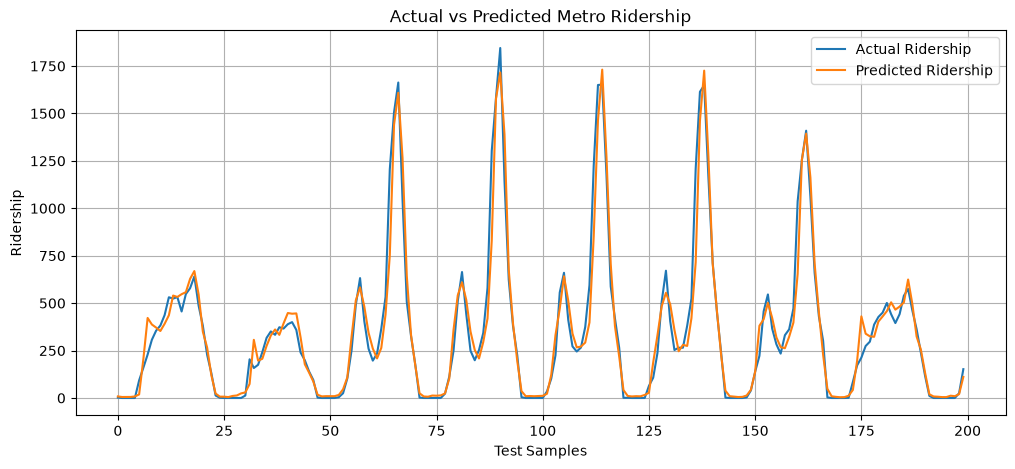

In [39]:
# Actual vs Predicted Ridership

plt.figure(figsize=(12, 5))

plt.plot(
    y_test.iloc[:200].values,
    label="Actual Ridership"
)

plt.plot(
    predictions[:200],
    label="Predicted Ridership"
)

plt.title("Actual vs Predicted Metro Ridership")
plt.xlabel("Test Samples")
plt.ylabel("Ridership")
plt.legend()
plt.grid(True)

plt.show()

In [40]:
comparison_df = pd.DataFrame({
    "Actual": y_test.iloc[:10].values,
    "Predicted": predictions[:10].round(0)
})

comparison_df

,Actual,Predicted
0,2.0,8.0
1,0.0,5.0
2,0.0,6.0
3,0.0,6.0
4,0.0,8.0
5,93.0,19.0
6,160.0,206.0
7,229.0,422.0
8,307.0,387.0
9,355.0,371.0


In [5]:
# Model A: Demand prediction WITHOUT weather features

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

features_no_weather = [
    "Station",
    "Hour",
    "DayOfWeek",
    "IsWeekend",
    "IsPeakHour",
    "Ridership"
]

X_no_weather = ml_df[features_no_weather]
y = ml_df["TargetRidership"]

split_index = int(len(ml_df) * 0.8)

X_train_no_weather = X_no_weather.iloc[:split_index]
X_test_no_weather = X_no_weather.iloc[split_index:]

y_train_no_weather = y.iloc[:split_index]
y_test_no_weather = y.iloc[split_index:]

preprocessor_no_weather = ColumnTransformer(
    transformers=[
        (
            "station",
            OneHotEncoder(handle_unknown="ignore"),
            ["Station"]
        )
    ],
    remainder="passthrough"
)

model_no_weather = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    objective="reg:squarederror",
    random_state=42
)

pipeline_no_weather = Pipeline([
    ("preprocessor", preprocessor_no_weather),
    ("model", model_no_weather)
])

pipeline_no_weather.fit(
    X_train_no_weather,
    y_train_no_weather
)

pred_no_weather = pipeline_no_weather.predict(
    X_test_no_weather
)

mae_no_weather = mean_absolute_error(
    y_test_no_weather,
    pred_no_weather
)

rmse_no_weather = np.sqrt(
    mean_squared_error(y_test_no_weather, pred_no_weather)
)

r2_no_weather = r2_score(
    y_test_no_weather,
    pred_no_weather
)

print("WITHOUT WEATHER")
print("MAE:", round(mae_no_weather, 2))
print("RMSE:", round(rmse_no_weather, 2))
print("R²:", round(r2_no_weather, 4))

WITHOUT WEATHER
MAE: 73.97
RMSE: 163.73
R²: 0.8728


In [6]:
# Recreate ML dataset

ml_df = merged_df.copy()

ml_df["DayOfWeek"] = ml_df["Date"].dt.dayofweek
ml_df["IsWeekend"] = (ml_df["DayOfWeek"] >= 5).astype(int)

ml_df["IsPeakHour"] = ml_df["Hour"].isin(
    [7, 8, 9, 17, 18, 19, 20]
).astype(int)

ml_df["IsRainy"] = (ml_df["prcp"] > 0).astype(int)

ml_df = ml_df.sort_values(
    ["Station", "Date", "Hour"]
).reset_index(drop=True)

ml_df["TargetRidership"] = (
    ml_df.groupby("Station")["Ridership"].shift(-1)
)

ml_df = ml_df.dropna(
    subset=["TargetRidership"]
).copy()

print("ML dataset ready:", ml_df.shape)

ML dataset ready: (92197, 17)


In [3]:
import pandas as pd
from pathlib import Path

# Load the saved merged dataset
merged_path = Path("../datasets/processed/metro_weather_merged.csv")

merged_df = pd.read_csv(merged_path)

# Convert Date back to datetime
merged_df["Date"] = pd.to_datetime(merged_df["Date"])

print("Merged dataset loaded successfully!")
print("Shape:", merged_df.shape)

Merged dataset loaded successfully!
Shape: (92280, 12)


In [4]:
# Prepare ML dataset

ml_df = merged_df.copy()

ml_df["DayOfWeek"] = ml_df["Date"].dt.dayofweek
ml_df["IsWeekend"] = (ml_df["DayOfWeek"] >= 5).astype(int)

ml_df["IsPeakHour"] = ml_df["Hour"].isin(
    [7, 8, 9, 17, 18, 19, 20]
).astype(int)

ml_df["IsRainy"] = (ml_df["prcp"] > 0).astype(int)

ml_df = ml_df.sort_values(
    ["Station", "Date", "Hour"]
).reset_index(drop=True)

ml_df["TargetRidership"] = (
    ml_df.groupby("Station")["Ridership"].shift(-1)
)

ml_df = ml_df.dropna(
    subset=["TargetRidership"]
).copy()

print("ML dataset ready!")
print("Shape:", ml_df.shape)

ML dataset ready!
Shape: (92197, 17)


In [7]:
# Create historical ridership features

ml_df = ml_df.sort_values(
    ["Station", "Date", "Hour"]
).reset_index(drop=True)

ml_df["Ridership_Lag_1"] = (
    ml_df.groupby("Station")["Ridership"].shift(1)
)

ml_df["Ridership_Lag_2"] = (
    ml_df.groupby("Station")["Ridership"].shift(2)
)

ml_df["Ridership_Lag_24"] = (
    ml_df.groupby("Station")["Ridership"].shift(24)
)

ml_df = ml_df.dropna(
    subset=[
        "Ridership_Lag_1",
        "Ridership_Lag_2",
        "Ridership_Lag_24",
        "TargetRidership"
    ]
).copy()

print("ML dataset with historical features:", ml_df.shape)

ML dataset with historical features: (90205, 20)


In [8]:
# Model C: Demand prediction using historical ridership + time + weather

features_final = [
    "Station",
    "Hour",
    "DayOfWeek",
    "IsWeekend",
    "IsPeakHour",
    "IsRainy",
    "Ridership",
    "Ridership_Lag_1",
    "Ridership_Lag_2",
    "Ridership_Lag_24",
    "temp",
    "rhum",
    "prcp",
    "wspd",
    "pres",
    "cldc",
    "coco"
]

X_final = ml_df[features_final]
y_final = ml_df["TargetRidership"]

# Chronological 80/20 split
split_index = int(len(ml_df) * 0.8)

X_train_final = X_final.iloc[:split_index]
X_test_final = X_final.iloc[split_index:]

y_train_final = y_final.iloc[:split_index]
y_test_final = y_final.iloc[split_index:]

# Encode station
preprocessor_final = ColumnTransformer(
    transformers=[
        (
            "station",
            OneHotEncoder(handle_unknown="ignore"),
            ["Station"]
        )
    ],
    remainder="passthrough"
)

# XGBoost
model_final = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    objective="reg:squarederror",
    random_state=42
)

pipeline_final = Pipeline([
    ("preprocessor", preprocessor_final),
    ("model", model_final)
])

# Train
pipeline_final.fit(
    X_train_final,
    y_train_final
)

# Predict
pred_final = pipeline_final.predict(X_test_final)

# Evaluate
mae_final = mean_absolute_error(
    y_test_final,
    pred_final
)

rmse_final = np.sqrt(
    mean_squared_error(y_test_final, pred_final)
)

r2_final = r2_score(
    y_test_final,
    pred_final
)

print("MODEL C — HISTORICAL RIDERSHIP + WEATHER")
print("MAE:", round(mae_final, 2))
print("RMSE:", round(rmse_final, 2))
print("R²:", round(r2_final, 4))

MODEL C — HISTORICAL RIDERSHIP + WEATHER
MAE: 72.62
RMSE: 166.02
R²: 0.8693


In [9]:
# Proper chronological train/test split

# Make sure data is sorted by time
ml_df = ml_df.sort_values(
    ["Date", "Hour", "Station"]
).reset_index(drop=True)

# Use the first 80% of dates for training
unique_dates = sorted(ml_df["Date"].dt.date.unique())

split_date = unique_dates[int(len(unique_dates) * 0.8)]

train_df = ml_df[
    ml_df["Date"].dt.date < split_date
].copy()

test_df = ml_df[
    ml_df["Date"].dt.date >= split_date
].copy()

print("Training period:")
print(train_df["Date"].min(), "to", train_df["Date"].max())

print("\nTesting period:")
print(test_df["Date"].min(), "to", test_df["Date"].max())

print("\nTraining rows:", len(train_df))
print("Testing rows:", len(test_df))

Training period:
2025-08-02 00:00:00 to 2025-09-20 00:00:00

Testing period:
2025-09-21 00:00:00 to 2025-09-30 00:00:00

Training rows: 70368
Testing rows: 19837


In [10]:
# Model A - Proper chronological evaluation WITHOUT weather

features_A = [
    "Station",
    "Hour",
    "DayOfWeek",
    "IsWeekend",
    "IsPeakHour",
    "Ridership"
]

X_train_A = train_df[features_A]
X_test_A = test_df[features_A]

y_train_A = train_df["TargetRidership"]
y_test_A = test_df["TargetRidership"]

preprocessor_A = ColumnTransformer(
    transformers=[
        (
            "station",
            OneHotEncoder(handle_unknown="ignore"),
            ["Station"]
        )
    ],
    remainder="passthrough"
)

model_A = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    objective="reg:squarederror",
    random_state=42
)

pipeline_A = Pipeline([
    ("preprocessor", preprocessor_A),
    ("model", model_A)
])

pipeline_A.fit(X_train_A, y_train_A)

pred_A = pipeline_A.predict(X_test_A)

mae_A = mean_absolute_error(y_test_A, pred_A)
rmse_A = np.sqrt(mean_squared_error(y_test_A, pred_A))
r2_A = r2_score(y_test_A, pred_A)

print("MODEL A — TIME + STATION + CURRENT RIDERSHIP")
print("MAE:", round(mae_A, 2))
print("RMSE:", round(rmse_A, 2))
print("R²:", round(r2_A, 4))

MODEL A — TIME + STATION + CURRENT RIDERSHIP
MAE: 46.64
RMSE: 85.14
R²: 0.9685


In [11]:
# Model B - Time + Station + Historical Ridership

features_B = [
    "Station",
    "Hour",
    "DayOfWeek",
    "IsWeekend",
    "IsPeakHour",
    "Ridership",
    "Ridership_Lag_1",
    "Ridership_Lag_2",
    "Ridership_Lag_24"
]

X_train_B = train_df[features_B]
X_test_B = test_df[features_B]

y_train_B = train_df["TargetRidership"]
y_test_B = test_df["TargetRidership"]

preprocessor_B = ColumnTransformer(
    transformers=[
        (
            "station",
            OneHotEncoder(handle_unknown="ignore"),
            ["Station"]
        )
    ],
    remainder="passthrough"
)

model_B = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    objective="reg:squarederror",
    random_state=42
)

pipeline_B = Pipeline([
    ("preprocessor", preprocessor_B),
    ("model", model_B)
])

pipeline_B.fit(X_train_B, y_train_B)

pred_B = pipeline_B.predict(X_test_B)

mae_B = mean_absolute_error(y_test_B, pred_B)
rmse_B = np.sqrt(mean_squared_error(y_test_B, pred_B))
r2_B = r2_score(y_test_B, pred_B)

print("MODEL B — HISTORICAL RIDERSHIP")
print("MAE:", round(mae_B, 2))
print("RMSE:", round(rmse_B, 2))
print("R²:", round(r2_B, 4))

MODEL B — HISTORICAL RIDERSHIP
MAE: 46.32
RMSE: 86.72
R²: 0.9673


In [12]:
# Model C - Time + Station + Historical Ridership + Weather

features_C = [
    "Station",
    "Hour",
    "DayOfWeek",
    "IsWeekend",
    "IsPeakHour",
    "IsRainy",
    "Ridership",
    "Ridership_Lag_1",
    "Ridership_Lag_2",
    "Ridership_Lag_24",
    "temp",
    "rhum",
    "prcp",
    "wspd",
    "pres",
    "cldc",
    "coco"
]

X_train_C = train_df[features_C]
X_test_C = test_df[features_C]

y_train_C = train_df["TargetRidership"]
y_test_C = test_df["TargetRidership"]

preprocessor_C = ColumnTransformer(
    transformers=[
        (
            "station",
            OneHotEncoder(handle_unknown="ignore"),
            ["Station"]
        )
    ],
    remainder="passthrough"
)

model_C = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    objective="reg:squarederror",
    random_state=42
)

pipeline_C = Pipeline([
    ("preprocessor", preprocessor_C),
    ("model", model_C)
])

pipeline_C.fit(X_train_C, y_train_C)

pred_C = pipeline_C.predict(X_test_C)

mae_C = mean_absolute_error(y_test_C, pred_C)
rmse_C = np.sqrt(mean_squared_error(y_test_C, pred_C))
r2_C = r2_score(y_test_C, pred_C)

print("MODEL C — HISTORICAL RIDERSHIP + WEATHER")
print("MAE:", round(mae_C, 2))
print("RMSE:", round(rmse_C, 2))
print("R²:", round(r2_C, 4))

MODEL C — HISTORICAL RIDERSHIP + WEATHER
MAE: 48.05
RMSE: 88.83
R²: 0.9657


In [13]:
import joblib
from pathlib import Path

final_model_path = Path("../models/metroflow_final_ridership_model.pkl")

joblib.dump(pipeline_A, final_model_path)

print("Final MetroFlow model saved successfully!")
print("Path:", final_model_path)

Final MetroFlow model saved successfully!
Path: ..\models\metroflow_final_ridership_model.pkl


In [16]:
# Compare evaluated models

model_results = pd.DataFrame({
    "Model": [
        "Model A: Time + Station",
        "Model B: Historical Ridership",
        "Model C: Historical Ridership + Weather",
        "Final Model: Historical Features + Weather",
        "No Weather Model"
    ],
    "MAE": [
        mae_A,
        mae_B,
        mae_C,
        mae_final,
        mae_no_weather
    ],
    "RMSE": [
        rmse_A,
        rmse_B,
        rmse_C,
        rmse_final,
        rmse_no_weather
    ],
    "R2": [
        r2_A,
        r2_B,
        r2_C,
        r2_final,
        r2_no_weather
    ]
})

model_results.sort_values("MAE").reset_index(drop=True)

,Model,MAE,RMSE,R2
0,Model B: Historical Ridership,46.322059,86.719953,0.967321
1,Model A: Time + Station,46.643040,85.141590,0.968500
2,Model C: Historical Ridership + Weather,48.052890,88.831682,0.965710
3,Final Model: Historical Features + Weather,72.621095,166.019099,0.869260
4,No Weather Model,73.970972,163.728454,0.872772


In [17]:
import joblib
from pathlib import Path

model_dir = Path("../models")
model_dir.mkdir(parents=True, exist_ok=True)

final_model_path = model_dir / "metroflow_final_ridership_model.pkl"

joblib.dump(pipeline_A, final_model_path)

print("Final model saved successfully!")
print("Path:", final_model_path)
print("Exists:", final_model_path.exists())

Final model saved successfully!
Path: ..\models\metroflow_final_ridership_model.pkl
Exists: True


In [18]:
# MetroFlow prediction demo

sample = test_df.iloc[[0]][[
    "Station",
    "Hour",
    "DayOfWeek",
    "IsWeekend",
    "IsPeakHour",
    "Ridership"
]]

predicted_ridership = pipeline_A.predict(sample)[0]

print("Station:", sample["Station"].iloc[0])
print("Hour:", sample["Hour"].iloc[0])
print("Current Ridership:", sample["Ridership"].iloc[0])
print("Predicted Next-Hour Ridership:", round(predicted_ridership))

Station: Attiguppe
Hour: 0
Current Ridership: 0
Predicted Next-Hour Ridership: -2


In [19]:
# Ensure predicted ridership cannot be negative

predictions_final = np.maximum(pred_A, 0)

print("Minimum prediction:", predictions_final.min())
print("Maximum prediction:", predictions_final.max())

Minimum prediction: 0.0
Maximum prediction: 4139.1587


In [20]:
# Test prediction on a high-demand example

sample_index = test_df["Ridership"].idxmax()

sample = test_df.loc[[sample_index], [
    "Station",
    "Hour",
    "DayOfWeek",
    "IsWeekend",
    "IsPeakHour",
    "Ridership"
]]

predicted = pipeline_A.predict(sample)[0]
predicted = max(0, predicted)

print("Station:", sample["Station"].iloc[0])
print("Hour:", sample["Hour"].iloc[0])
print("Current Ridership:", sample["Ridership"].iloc[0])
print("Predicted Next-Hour Ridership:", round(predicted))

Station: Benniganahalli
Hour: 9
Current Ridership: 4312
Predicted Next-Hour Ridership: 3181


In [21]:
# Create station-specific demand thresholds

station_thresholds = (
    train_df.groupby("Station")["Ridership"]
    .quantile([0.50, 0.80, 0.95])
    .unstack()
    .reset_index()
)

station_thresholds.columns = [
    "Station",
    "Medium_Threshold",
    "High_Threshold",
    "Very_High_Threshold"
]

station_thresholds.head()

,Station,Medium_Threshold,High_Threshold,Very_High_Threshold
0,Attiguppe,281.5,446.0,1428.25
1,BTM Layout,151.5,272.0,397.65
2,Baiyappanahalli,463.0,836.6,1966.05
3,Banashankari,536.5,875.0,1175.95
4,Benniganahalli,1067.0,1718.0,3247.60


In [22]:
# Create crowd level for predictions

prediction_results = test_df[
    ["Date", "Hour", "Station", "Ridership", "TargetRidership"]
].copy()

prediction_results["PredictedRidership"] = np.maximum(pred_A, 0)

prediction_results = prediction_results.merge(
    station_thresholds,
    on="Station",
    how="left"
)

def classify_crowd(row):
    if row["PredictedRidership"] >= row["Very_High_Threshold"]:
        return "Very High"
    elif row["PredictedRidership"] >= row["High_Threshold"]:
        return "High"
    elif row["PredictedRidership"] >= row["Medium_Threshold"]:
        return "Medium"
    else:
        return "Low"

prediction_results["CrowdLevel"] = prediction_results.apply(
    classify_crowd,
    axis=1
)

prediction_results.head(10)

,Date,Hour,Station,Ridership,TargetRidership,PredictedRidership,Medium_Threshold,High_Threshold,Very_High_Threshold,CrowdLevel
0,2025-09-21,0,Attiguppe,0,0.0,0.0,281.5,446.0,1428.25,Low
1,2025-09-21,0,BTM Layout,0,0.0,0.0,151.5,272.0,397.65,Low
2,2025-09-21,0,Baiyappanahalli,0,0.0,0.0,463.0,836.6,1966.05,Low
3,2025-09-21,0,Banashankari,0,0.0,0.0,536.5,875.0,1175.95,Low
4,2025-09-21,0,Benniganahalli,2,0.0,0.0,1067.0,1718.0,3247.60,Low
5,2025-09-21,0,Beratena Agrahara,0,0.0,0.0,26.0,54.6,88.65,Low
6,2025-09-21,0,Biocon Hebbagodi,0,0.0,0.0,60.0,121.6,173.65,Low
7,2025-09-21,0,Bommanahalli,0,0.0,0.0,164.0,312.6,451.30,Low
8,2025-09-21,0,Central Silk Board,1,0.0,0.0,196.5,361.8,582.30,Low
9,2025-09-21,0,Challaghatta,0,0.0,0.0,288.5,487.0,683.95,Low


In [23]:
# Crowd management recommendation

def get_recommendation(crowd_level):
    if crowd_level == "Very High":
        return "Increase service frequency and closely monitor crowding"
    elif crowd_level == "High":
        return "Monitor station closely and consider additional service"
    elif crowd_level == "Medium":
        return "Maintain normal service and continue monitoring"
    else:
        return "Normal/off-peak operations"

prediction_results["Recommendation"] = (
    prediction_results["CrowdLevel"]
    .apply(get_recommendation)
)

prediction_results[
    [
        "Date",
        "Hour",
        "Station",
        "Ridership",
        "PredictedRidership",
        "CrowdLevel",
        "Recommendation"
    ]
].head(20)

,Date,Hour,Station,Ridership,PredictedRidership,CrowdLevel,Recommendation
0,2025-09-21,0,Attiguppe,0,0.000000,Low,Normal/off-peak operations
1,2025-09-21,0,BTM Layout,0,0.000000,Low,Normal/off-peak operations
2,2025-09-21,0,Baiyappanahalli,0,0.000000,Low,Normal/off-peak operations
3,2025-09-21,0,Banashankari,0,0.000000,Low,Normal/off-peak operations
4,2025-09-21,0,Benniganahalli,2,0.000000,Low,Normal/off-peak operations
5,2025-09-21,0,Beratena Agrahara,0,0.000000,Low,Normal/off-peak operations
6,2025-09-21,0,Biocon Hebbagodi,0,0.000000,Low,Normal/off-peak operations
7,2025-09-21,0,Bommanahalli,0,0.000000,Low,Normal/off-peak operations
8,2025-09-21,0,Central Silk Board,1,0.000000,Low,Normal/off-peak operations
9,2025-09-21,0,Challaghatta,0,0.000000,Low,Normal/off-peak operations


In [24]:
# Crowd-level summary

crowd_summary = (
    prediction_results["CrowdLevel"]
    .value_counts()
    .reindex(
        ["Low", "Medium", "High", "Very High"],
        fill_value=0
    )
)

crowd_summary

CrowdLevel
Low          9392
Medium       6218
High         3246
Very High     981
Name: count, dtype: int64

In [25]:
# Save MetroFlow prediction and crowd-management results

results_path = Path(
    "../datasets/processed/metroflow_predictions.csv"
)

prediction_results.to_csv(
    results_path,
    index=False
)

print("Prediction results saved successfully!")
print("Rows:", len(prediction_results))
print("Path:", results_path)

Prediction results saved successfully!
Rows: 19837
Path: ..\datasets\processed\metroflow_predictions.csv


In [26]:
print(results_path.exists())

True


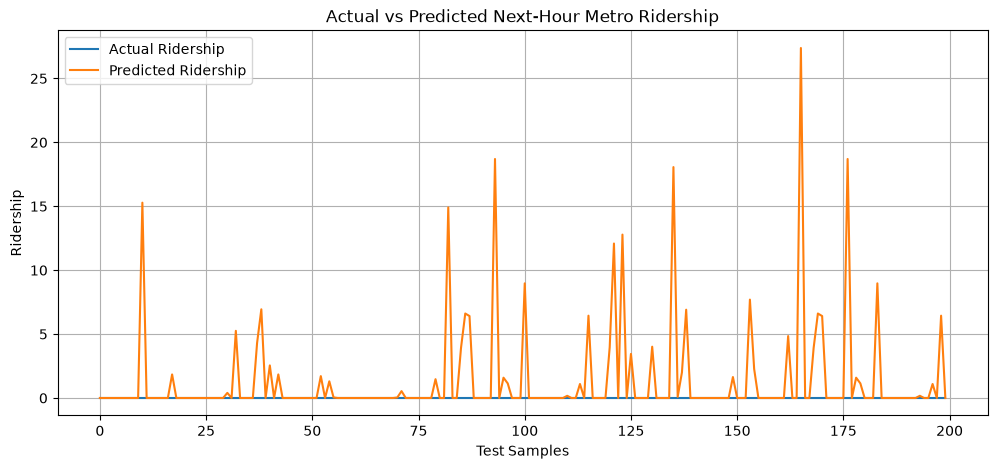

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Actual vs Predicted Ridership

plt.figure(figsize=(12, 5))

plt.plot(
    y_test_A.iloc[:200].values,
    label="Actual Ridership"
)

plt.plot(
    np.maximum(pred_A[:200], 0),
    label="Predicted Ridership"
)

plt.title("Actual vs Predicted Next-Hour Metro Ridership")
plt.xlabel("Test Samples")
plt.ylabel("Ridership")
plt.legend()
plt.grid(True)

plt.show()

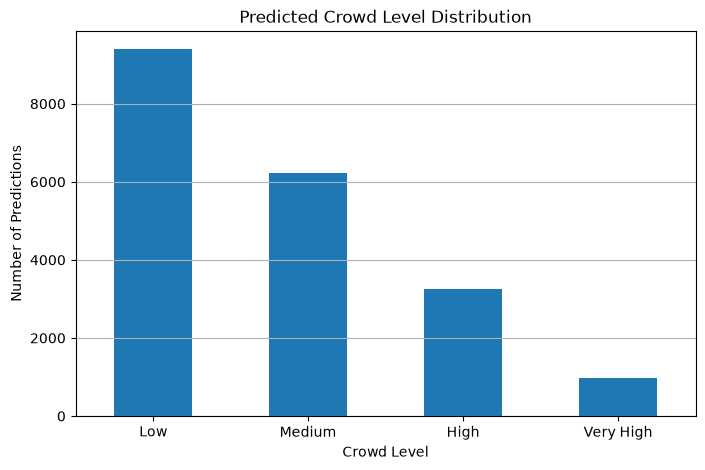

In [29]:
# Crowd level distribution

crowd_summary.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Predicted Crowd Level Distribution")
plt.xlabel("Crowd Level")
plt.ylabel("Number of Predictions")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()